## Plot Total Organic Column

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as pl
import matplotlib.pyplot as plt
from pathlib import Path
import dill
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
import matplotlib.lines as mlines
import re

In [16]:
data = {}

for d in Path("../ModelOutputs/OrganicSoil/TotalOrganic").glob("VWC_*.dill"):
    with open(d, "rb") as f:
        out = dill.load(f)

    data[d.stem] = out   

In [17]:
first_key = list(data.keys())[0]
out = data[first_key]

In [18]:
T_dfs = {}

for run_name, out in data.items():
    try:
        # extract theta1 from filename
        m = re.search(r"th1_(\d+\.\d+)", run_name)
        th1 = float(m.group(1))*100   # keep as float (0.10, 0.50, etc.)

        # build dataframe
        df = pd.DataFrame(
            out.T,
            columns=out.z,   # real depths (much better than Depth_0 etc.)
            index=out.t
        )
        # store
        T_dfs[f"df_{th1:.0f}"] = df

    except Exception as e:
        print(f"Skipped {run_name}: {e}")

In [19]:
thetaL = out.thetaL

thetaL_dfs = {}

for run_name, out in data.items():
    try:
        # extract theta1 from filename
        m = re.search(r"th1_(\d+\.\d+)", run_name)
        th1 = float(m.group(1))*100

        # build liquid water content dataframe
        df = pd.DataFrame(
            out.thetaL,
            columns=out.z,
            index=out.t
        )

        thetaL_dfs[f"df_{th1:.0f}"] = df

    except Exception as e:
        print(f"Skipped {run_name}: {e}")
print(out.thetaL.shape)

(1461, 1250)


In [20]:
J_dfs = {}

for run_name, out in data.items():
    try:
        # extract theta1 from filename
        m = re.search(r"th1_(\d+\.\d+)", run_name)
        th1 = float(m.group(1))*100   # keep as float (0.10, 0.50, etc.)

        # build dataframe
        df = pd.DataFrame(
            out.jT,   # real depths (much better than Depth_0 etc.)
            index=out.t
        )
        # store
        J_dfs[f"df_{th1:.0f}"] = df

    except Exception as e:
        print(f"Skipped {run_name}: {e}")

In [21]:
def fake_date(df):
    dfe = df.iloc[74:].reset_index(drop = True)
    n = len(dfe)
    dates = pd.date_range("2000-01-01", periods=n, freq="D")
    dfe.index = dates
    return dfe

In [22]:
# apply fake date to all dataframes and changes them in dictionary
T_dfse = {}
T_dfse = {key: fake_date(df) for key, df in T_dfs.items()}

In [23]:
# apply fake date to all dataframes and changes them in dictionary
J_dfse = {}
J_dfse = {key: fake_date(df) for key, df in J_dfs.items()}

In [24]:
# Create Mesh
nz=1250
dz=np.zeros(nz)+0.01
dz[:500] = 0.01 # 0 -5
dz[500:] = 0.02 # 5m - 20m
bz=np.hstack([0, np.cumsum(dz)])
z=(bz[:-1]+bz[1:])/2
zMax=bz[-1]

In [25]:
def depths(df,z):
    z1 = np.round(z, 3)
    df.columns = z1
    return df

In [26]:
# apply depths to all the dataframes
T_dfs = {key: depths(df,z) for key, df in T_dfs.items()}
T_dfse = {key: depths(df,z) for key, df in T_dfse.items()}

In [27]:
def depths(df):
    z1 = np.round(z, 3)
    df.columns = z1
    return df

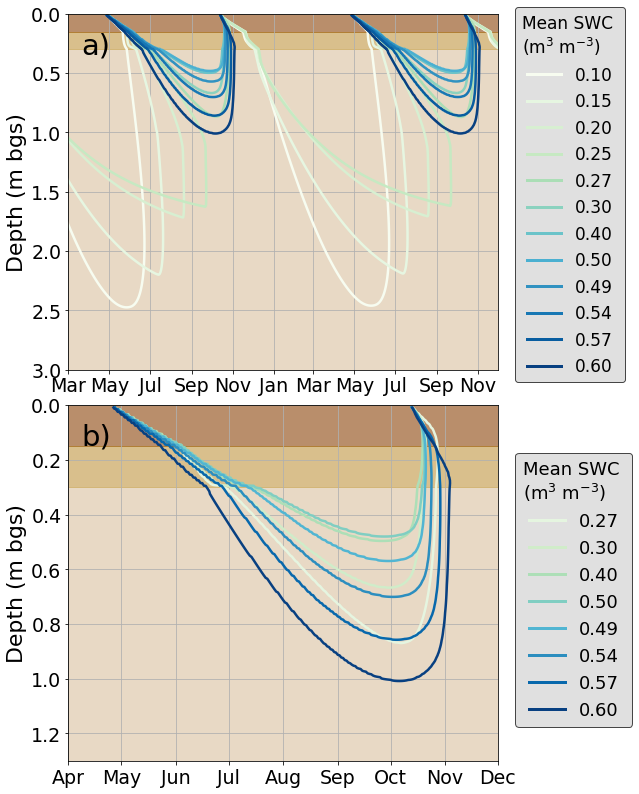

In [28]:

# ============================================================
# DATASETS
# ============================================================

datasets = (T_dfse['df_10'],T_dfse['df_15'],T_dfse['df_20'], T_dfse['df_25'], T_dfse['df_27'], 
            T_dfse['df_30'], T_dfse['df_40'],T_dfse['df_50'],T_dfse['df_60'], T_dfse['df_70'], T_dfse['df_80'],T_dfse['df_93'])

labels = ('0.10','0.15','0.20','0.25','0.27','0.30','0.40','0.50','0.49','0.54','0.57','0.60')

# ============================================================
# FIGURE
# ============================================================

fig, ax = plt.subplots(
    2, 1,
    figsize=(9, 12))

# ============================================================
# PANEL A
# ============================================================

# Background
ax[0].axhspan(0.0, 5, color='tan', alpha=0.5)

# Organic layers
ax[0].axhspan(
    0.0, 0.15,
    color='saddlebrown',
    alpha=0.5)

ax[0].axhspan(
    0.15, 0.30,
    color='darkgoldenrod',
    alpha=0.3)

# Colors
blues = plt.cm.GnBu(
    np.linspace(0, 1, len(datasets)))

# ------------------------------------------------------------
# 0 °C contours
# ------------------------------------------------------------

for data, vwc, color in zip(datasets, labels, blues):

    # For wetter simulations, don't search for the 0°C contour
    # below 2 m
    if float(vwc) >= 0.27:
        data_plot = data.loc[
            :,
            data.columns.astype(float) <= 1.5]
    else:
        data_plot = data

    Time, Depth = np.meshgrid(
        data_plot.index,
        data_plot.columns.astype(float),
        indexing='ij')

    ax[0].contour(
        Time,
        Depth,
        data_plot.values,
        levels=[0],
        colors=[color],
        linewidths=2.5)

# ------------------------------------------------------------
# Legend
# ------------------------------------------------------------

legend_lines = [
    mlines.Line2D(
        [],
        [],
        color=color,
        lw=3,
        label=label
    )
    for color, label in zip(blues, labels)
]

leg = ax[0].legend(
    handles=legend_lines,
    loc='lower left',
    bbox_to_anchor=(1.02, -0.06),
    fontsize=17,
    title='Mean SWC \n(m$^3$ m$^{-3}$)',
    title_fontproperties={'size': 17}
)

leg.get_frame().set_facecolor('lightgrey')
leg.get_frame().set_alpha(0.7)
leg.get_frame().set_edgecolor('black')

# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------

ax[0].invert_yaxis()

ax[0].set_ylim(3,0)

ax[0].set_ylabel(
    "Depth (m bgs)",
    fontsize=22)

ax[0].tick_params(
    axis='both',
    labelsize=19)

ax[0].grid()

start_date = pd.to_datetime('2001-03-01')
end_date = pd.to_datetime('2002-12-01')

ax[0].set_xlim(
    start_date,
    end_date)

ax[0].xaxis.set_major_formatter(
    mdates.DateFormatter('%b'))

ax[0].text(
    0.03,
    0.95,
    "a)",
    transform=ax[0].transAxes,
    fontsize=29,
    va='top')

# ============================================================
# PANEL B
# ============================================================

datasets2 = ( T_dfse['df_27'],T_dfse['df_30'],  T_dfse['df_40'],  T_dfse['df_50'], T_dfse['df_60'], T_dfse['df_70'], T_dfse['df_80'],  T_dfse['df_93'])

labels2 = ('0.27','0.30','0.40','0.50','0.49','0.54','0.57','0.60')

# Background
ax[1].axhspan(
    0.0,
    5,
    color='tan',
    alpha=0.5
)

# Organic layers
ax[1].axhspan(
    0.0,
    0.15,
    color='saddlebrown',
    alpha=0.5)

ax[1].axhspan(
    0.15,
    0.30,
    color='darkgoldenrod',
    alpha=0.3)

# Colors
blues2 = plt.cm.GnBu(
    np.linspace(0.1, 1, len(datasets2)))

# ------------------------------------------------------------
# 0 °C contours
# ------------------------------------------------------------

for data, vwc, color in zip(
    datasets2,
    labels2,
    blues2):

    # Same depth restriction
    if float(vwc) >= 0.27:
        data_plot = data.loc[
            :,
            data.columns.astype(float) <= 2.0
        ]
    else:
        data_plot = data

    Time, Depth = np.meshgrid(
        data_plot.index,
        data_plot.columns.astype(float),
        indexing='ij'    )

    ax[1].contour(
        Time,
        Depth,
        data_plot.values,
        levels=[0],
        colors=[color],
        linewidths=2.5  )

# ------------------------------------------------------------
# Legend
# ------------------------------------------------------------

legend_lines2 = [
    mlines.Line2D(
        [],
        [],
        color=color,
        lw=3,
        label=label
    )
    for color, label in zip(blues2, labels2)]

leg2 = ax[1].legend(
    handles=legend_lines2,
    loc='lower left',
    bbox_to_anchor=(1.02, 0.07),
    fontsize=18,
    title='Mean SWC \n(m$^3$ m$^{-3}$)',
    title_fontproperties={'size': 18})

leg2.get_frame().set_facecolor('lightgrey')
leg2.get_frame().set_alpha(0.7)
leg2.get_frame().set_edgecolor('black')

# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------

ax[1].invert_yaxis()

ax[1].set_ylim(
    1.3,
    0)

ax[1].set_ylabel(
    "Depth (m bgs)",
    fontsize=22)

ax[1].tick_params(
    axis='both',
    labelsize=19)

ax[1].grid()

start_date2 = pd.to_datetime('2002-04-01')
end_date2 = pd.to_datetime('2002-12-01')

ax[1].set_xlim(
    start_date2,
    end_date2)

ax[1].xaxis.set_major_formatter(
    mdates.DateFormatter('%b'))

ax[1].text(
    0.03,
    0.95,
    "b)",
    transform=ax[1].transAxes,
    fontsize=29,
    va='top')

# ============================================================
# FINAL LAYOUT
# ============================================================

fig.tight_layout()

fig.subplots_adjust(
    hspace=0.1
)


Mean SWC = 0.40: shading based on 0.855 m
Mean SWC = 0.40: 0 days between -0.05 and 0.0 °C
Mean SWC = 0.54: shading based on 0.855 m
Mean SWC = 0.54: 0 days between -0.05 and 0.0 °C
Mean SWC = 0.59: shading based on 0.855 m
Mean SWC = 0.59: 99 days between -0.05 and 0.0 °C


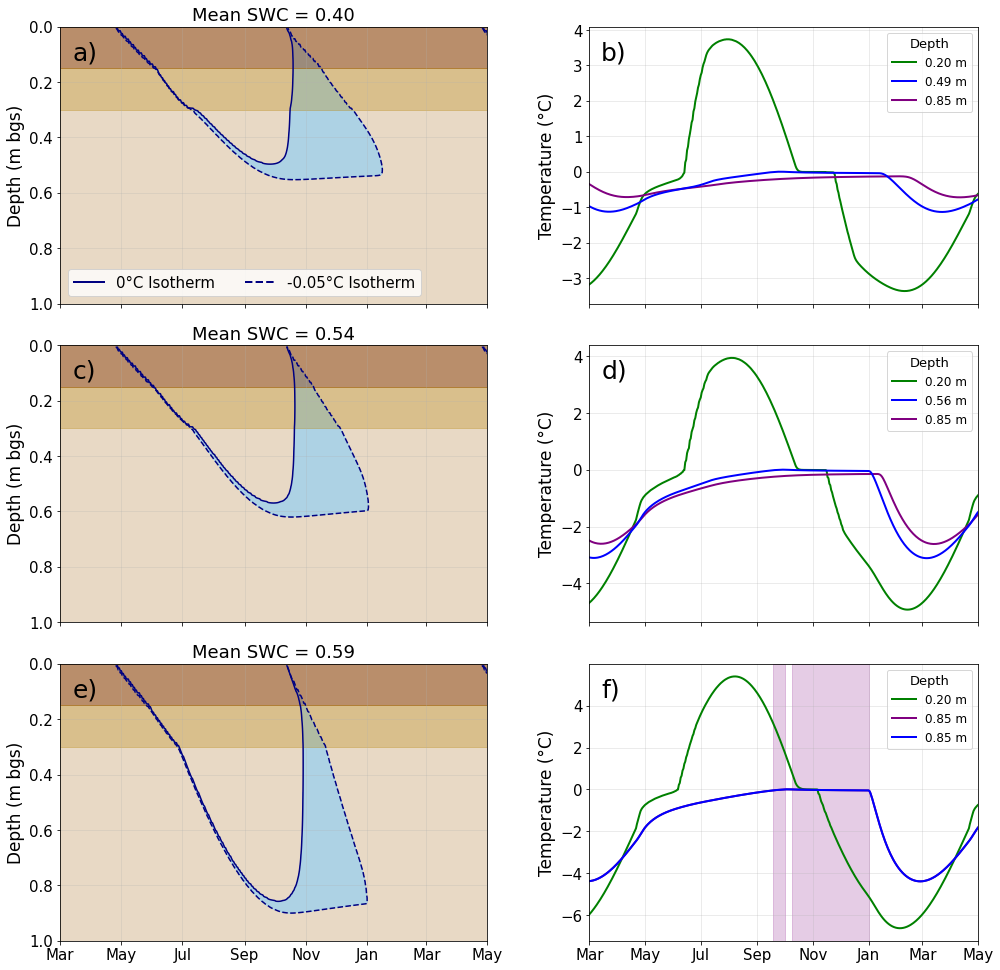

In [29]:

# ============================================================
# PANEL A
# ============================================================

water_contents = ['df_40', 'df_60','df_80']
titles = ['Mean SWC = 0.40', 'Mean SWC = 0.54', 'Mean SWC = 0.59']

# Common middle depth
a = 0.859
# Temperatures to plot in each row
plot_depths = [
    [0.20, a, 0.497],   # SWC 0.40
    [0.20, a, 0.57],   # SWC 0.60
    [0.20, a, 0.859]]    # SWC 0.80]

# Depth used to calculate the shaded zero-curtain period
shade_depths = [a,   a,   a ]
# Temperature range for LEFT contour shading
contour_lower = -0.05
contour_upper = 0.0

# Temperature range used for RIGHT zero-curtain shading
shade_lower = -0.05
shade_upper = 0.0

# Date ranges
start_date = pd.to_datetime('2002-03-01')
end_date = pd.to_datetime('2003-05-01')

freeze_start = pd.Timestamp('2002-09-01')
freeze_end = pd.Timestamp('2003-06-01')

# Line colors for temperature depths
colors = ['green', 'purple', 'blue']

# ============================================================
# FIGURE
# ============================================================
fig, ax = plt.subplots(
    3, 2,
    figsize=(14, 14),
    gridspec_kw={'width_ratios': [1.1, 1]},
    sharex='col')
# ============================================================
# LOOP THROUGH WATER CONTENTS
# ============================================================
for i, (wc, title) in enumerate(zip(water_contents, titles)):

    data = T_dfse[wc]
    depth_cols = data.columns.astype(float)

    Time, Depth = np.meshgrid(
        data.index,
        depth_cols,
        indexing='ij')
    # ========================================================
    # LEFT PANEL: ISOTHERMS
    # ========================================================

    left = ax[i, 0]
    # Background soil shading
    left.axhspan(
        0,
        5,
        color='tan',
        alpha=0.5)

    # Temperature-zone shading
    left.contourf(
        Time,
        Depth,
        data.values,
        levels=[contour_lower, contour_upper],
        colors=['lightskyblue'],
        alpha=0.6)

    # Isotherm lines
    left.contour(
        Time,
        Depth,
        data.values,
        levels=[contour_lower, contour_upper],
        colors='navy',
        linestyles=['--', '-'],
        linewidths=1.5)

    left.invert_yaxis()
    left.set_ylim(1.0, 0)
    left.set_xlim(start_date, end_date)
    left.set_ylabel(
        "Depth (m bgs)",
        fontsize=17)
    
        # Background
    # Organic layers
    left.axhspan(
        0.0, 0.15,
        color='saddlebrown',
        alpha=0.5)

    left.axhspan(
        0.15, 0.30,
        color='darkgoldenrod',
        alpha=0.3)

    left.set_title(
        title,
        fontsize=18)
    left.tick_params(
        axis='both',
        labelsize=15)
    left.grid(alpha=0.3)
    # ========================================================
    # RIGHT PANEL: TEMPERATURE
    # ========================================================
    right = ax[i, 1]

    for d, c in zip(plot_depths[i], colors):

        # Find closest model depth that is <= requested depth
        valid = np.where(depth_cols <= d)[0]
        col = valid[-1]

        actual_depth = depth_cols[col]
        temp = data.iloc[:, col]

        right.plot(data.index, temp, color=c, lw=2, label=f'{actual_depth:.2f} m')
        # ========================================================
        # TEMPERATURE SERIES USED FOR SHADING
    # ========================================================

    shade_depth = shade_depths[i]

    shade_col = np.argmin(
        np.abs(depth_cols - shade_depth))

    actual_shade_depth = depth_cols[shade_col]
    temp_shade = data.iloc[:, shade_col]

    print(
        f'{title}: shading based on '
        f'{actual_shade_depth:.3f} m')

    # Identify times in selected temperature range
    mask = (
        (temp_shade.index >= freeze_start) &
        (temp_shade.index <= freeze_end) &
        (temp_shade <= shade_upper) &
        (temp_shade >= shade_lower))

    days_in_range = mask.sum()

    print(
        f'{title}: {days_in_range} days between '
        f'{shade_lower} and {shade_upper} °C')

    # ========================================================
    # SHADE CONTINUOUS PERIODS
    # ========================================================

    in_region = False

    for j in range(len(mask)):

        if mask.iloc[j] and not in_region:

            start = temp_shade.index[j]
            in_region = True

        elif not mask.iloc[j] and in_region:

            right.axvspan(
                start,
                temp_shade.index[j - 1],
                color='purple',
                alpha=0.2,
                zorder=0)
            in_region = False

    # If final shaded region reaches end of series
    if in_region:

        right.axvspan(
            start,
            temp_shade.index[-1],
            color='purple',
            alpha=0.2,
            zorder=0)

    # ========================================================
    # RIGHT PANEL FORMATTING
    # ========================================================

    right.set_xlim(
        start_date,
        end_date)

    right.set_ylabel(
        "Temperature (°C)",
        fontsize=17 )

    right.tick_params(
        axis='both',
        labelsize=15 )

    right.grid(alpha=0.3)
    # Sort legend entries by depth
    handles, legend_labels = right.get_legend_handles_labels()
    order = np.argsort(
        [
            float(label.split()[0])
            for label in legend_labels])
    right.legend(
        [handles[j] for j in order],
        [legend_labels[j] for j in order],
        title="Depth",
        fontsize=12,
        title_fontsize=13,
        loc='best',
        framealpha=0.8)
# ============================================================
# ISOTHERM LEGEND
# ============================================================

isotherm_line1 = Line2D(
    [0], [0],
    color='navy',
    lw=2,
    linestyle='-',
    label='0°C Isotherm')

isotherm_line2 = Line2D(
    [0], [0],
    color='navy',
    lw=2,
    linestyle='--',
    label=f'{contour_lower:.2f}°C Isotherm')

ax[0, 0].legend(
    handles=[
        isotherm_line1,
        isotherm_line2
    ],
    ncol=2,
    fontsize=15,
    frameon=True,
    loc='lower left')

# ============================================================
# PANEL LABELS
# ============================================================

panel_labels = [
    'a)', 'b)',
    'c)', 'd)',
    'e)', 'f)']

for a_ax, label in zip(
    ax.flatten(),
    panel_labels):

    a_ax.text(
        0.03,
        0.95,
        label,
        transform=a_ax.transAxes,
        fontsize=25,
        va='top')
# ============================================================
# X-AXIS FORMATTING
# ============================================================
for a_ax in ax.flatten():

    a_ax.xaxis.set_major_formatter(
        mdates.DateFormatter('%b'))

# Optional:
# ax[2, 1].set_ylim(-0.04, 0.00)
# ============================================================
# FINAL LAYOUT
# ============================================================

plt.tight_layout(
    rect=[0, 0, 1, 0.97])

plt.subplots_adjust(
    hspace=0.15,
    
    wspace=0.25)

In [30]:
dfs = [T_dfs['df_10'],T_dfs['df_15'],T_dfs['df_20'],T_dfs['df_25'],T_dfs['df_27'],T_dfs['df_30'],T_dfs['df_40'],T_dfs['df_50'], T_dfs['df_60'], T_dfs['df_70'],T_dfs['df_80'],T_dfs['df_93']]

In [31]:
def surface_thaw_depth(row, depths):
    vals = row.values.astype(float)

    # If surface is frozen, no active-layer thaw
    if vals[0] < 0:
        return 0.0

    # Find first frozen point below the surface
    frozen = np.where(vals < 0)[0]

    if len(frozen) == 0:
        return depths[-1]

    i = frozen[0]

    # First point is frozen
    if i == 0:
        return 0.0

    # Linear interpolation to 0°C crossing
    T1, T2 = vals[i-1], vals[i]
    z1, z2 = depths[i-1], depths[i]

    z0 = z1 + (0 - T1) * (z2 - z1) / (T2 - T1)

    return z0

In [32]:
def equilibriated(df, start=900, end=1450, tol=0.01):

    depths = df.columns.astype(float).values
    L = end - start

    # ---- Last year ----
    sub1 = df.iloc[start:end]

    thaw1 = sub1.apply(
        lambda row: surface_thaw_depth(row, depths),
        axis=1
    )

    d1 = thaw1.max()

    # ---- Previous year ----
    sub2 = df.iloc[start-L:start]

    thaw2 = sub2.apply(
        lambda row: surface_thaw_depth(row, depths),
        axis=1
    )

    d2 = thaw2.max()

    # ---- Compare ----
    diff = abs(d1 - d2)

    if diff <= tol:
        print(
            f"Equilibrated: {d1:.3f} vs {d2:.3f} "
            f"(diff = {diff:.4f})"
        )
    else:
        print(
            f"Different: {d1:.3f} vs {d2:.3f} "
            f"(diff = {diff:.4f})"
        )

    return d1, d2

In [33]:
for df in dfs:
    equilibriated(df)

Equilibrated: 19.990 vs 19.990 (diff = 0.0000)
Equilibrated: 19.990 vs 19.990 (diff = 0.0000)
Equilibrated: 19.990 vs 19.990 (diff = 0.0000)
Equilibrated: 19.990 vs 19.990 (diff = 0.0000)
Equilibrated: 0.873 vs 0.865 (diff = 0.0081)
Equilibrated: 0.667 vs 0.668 (diff = 0.0006)
Equilibrated: 0.496 vs 0.497 (diff = 0.0006)
Equilibrated: 0.480 vs 0.481 (diff = 0.0006)
Equilibrated: 0.570 vs 0.570 (diff = 0.0005)
Equilibrated: 0.701 vs 0.702 (diff = 0.0009)
Equilibrated: 0.858 vs 0.859 (diff = 0.0011)
Equilibrated: 1.008 vs 1.009 (diff = 0.0010)


In [34]:
dfs = [T_dfs['df_20'],T_dfs['df_30'],T_dfs['df_40'],T_dfs['df_50'], T_dfs['df_60'], T_dfs['df_70'],T_dfs['df_80'],T_dfs['df_93']]

In [35]:

ALT = [0.865,0.688, 0.497, 0.481, 0.57, 0.702, 0.859, 1.009]
VWC = [0.27,0.3, 0.4, 0.49247401, 0.54315789, 0.57401709, 0.59175786, 0.59892963]

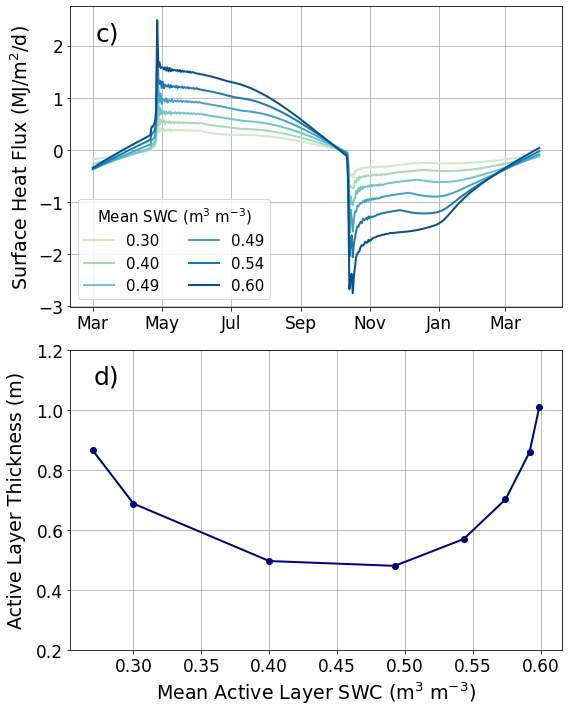

In [36]:
import numpy as np
import matplotlib.pyplot as pl

fig, ax = pl.subplots(2, 1, figsize=(8, 10))

a = '2001-03'
b = '2002-03'

# ---------- TOP PANEL (unchanged) ----------

ax[1].plot(
    VWC, ALT,
    label='0.60',
    color='navy',
    linewidth=2, marker = 'o'
)
#ax[0].set_ylim(-1,0.05)
ax[0].xaxis.set_major_formatter(pl.matplotlib.dates.DateFormatter('%b'))

# ---------- BOTTOM PANEL (GnBu gradient) ----------

# J datasets and labels (ordered low → high VWC)
J_datasets = (
    J_dfse['df_30'].loc[a:b] / 1e6,
    J_dfse['df_40'].loc[a:b] / 1e6,
    J_dfse['df_50'].loc[a:b] / 1e6,
    J_dfse['df_60'].loc[a:b] / 1e6,
    J_dfse['df_70'].loc[a:b] / 1e6,
    J_dfse['df_80'].loc[a:b] / 1e6,)

J_labels = ('0.30','0.40','0.49','0.49','0.54','0.60')

# Light → dark GnBu
gnbu = pl.cm.GnBu(np.linspace(0.25, 0.95, len(J_datasets)))

for data, label, color in zip(J_datasets, J_labels, gnbu):
    ax[0].plot(data, label=label, color=color, linewidth=2)

ax[0].xaxis.set_major_formatter(pl.matplotlib.dates.DateFormatter('%b'))

# ---------- LEGENDS & LABELS ----------
ax[0].legend(
    fontsize=15,
    loc='lower left',
    title='Mean SWC (m$^3$ m$^{-3}$)',
    title_fontsize=15, ncol = 2)

ax[0].set_ylabel('Surface Heat Flux (MJ/m$^2$/d)', fontsize=19)
ax[1].set_ylabel('Active Layer Thickness (m)', fontsize=19, labelpad=10)

ax[0].tick_params(axis='both', labelsize=17)
ax[1].tick_params(axis='both', labelsize=17)

fig.subplots_adjust(hspace=0.1)

# ---------- PANEL LABELS ----------
ax[0].text(
    0.1, 0.87, "c)",
    transform=ax[0].transAxes,
    fontsize=25,
    ha="right",
    va="bottom")

ax[1].text(
    0.1, 0.87, "d)",
    transform=ax[1].transAxes,
    fontsize=25,
    ha="right",
    va="bottom")

ax[1].set_ylim(0.2,1.2)
#ax[1].set_ylim(1.3,0)
ax[1].set_xlabel('Mean Active Layer SWC (m$^3$ m$^{-3}$)', fontsize = 19)

pl.tight_layout()
ax[0].grid()
ax[1].grid()
